In [1]:
%%capture
import os

!pip install pip3-autoremove
!pip install torch torchvision torchaudio xformers --index-url https://download.pytorch.org/whl/cu128
!pip install unsloth
!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2
!pip -q install -U peft transformers accelerate

### Unsloth

In [2]:
from unsloth import FastLanguageModel
import torch
max_seq_length = 2048 # Choose any! We auto support RoPE Scaling internally!
dtype = None # None for auto detection. Float16 for Tesla T4, V100, Bfloat16 for Ampere+
load_in_4bit = True # Use 4bit quantization to reduce memory usage. Can be False.

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Qwen2.5-7B",
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit,
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


2026-01-07 11:09:56.124814: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767784196.403163      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767784196.504047      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767784197.219115      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767784197.219152      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767784197.219156      55 computation_placer.cc:177] computation placer alr

🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth: Could not import trl.trainer.alignprop_trainer: Failed to import trl.trainer.alignprop_trainer because of the following error (look up to see its traceback):
Failed to import trl.models.modeling_sd_base because of the following error (look up to see its traceback):
Failed to import diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion because of the following error (look up to see its traceback):
Failed to import diffusers.loaders.ip_adapter because of the following error (look up to see its traceback):
/usr/local/lib/python3.12/dist-packages/xformers/flash_attn_3/_C.so: undefined symbol: _ZNK3c106SymInt22maybe_as_int_slow_pathEv
Unsloth: Could not import trl.trainer.ddpo_trainer: Failed to import trl.trainer.ddpo_trainer because of the following error (look up to see its traceback):
Failed to import trl.models.modeling_sd_base because of the following error (look up to see its traceback):
Failed to impo

model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

We now add LoRA adapters so we only need to update 1 to 10% of all parameters!

In [3]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 16, # Choose any number > 0 ! Suggested 8, 16, 32, 64, 128
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj",],
    lora_alpha = 16,
    lora_dropout = 0, # Supports any, but = 0 is optimized
    bias = "none",    # Supports any, but = "none" is optimized
    # [NEW] "unsloth" uses 30% less VRAM, fits 2x larger batch sizes!
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for very long context
    random_state = 3407,
    use_rslora = False,  # We support rank stabilized LoRA
    loftq_config = None, # And LoftQ
)

Unsloth 2026.1.2 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


<a name="Data"></a>
### Data Prep
We now use the Alpaca dataset from [yahma](https://huggingface.co/datasets/yahma/alpaca-cleaned), which is a filtered version of 52K of the original [Alpaca dataset](https://crfm.stanford.edu/2023/03/13/alpaca.html). You can replace this code section with your own data prep.

**[NOTE]** To train only on completions (ignoring the user's input) read TRL's docs [here](https://huggingface.co/docs/trl/sft_trainer#train-on-completions-only).

**[NOTE]** Remember to add the **EOS_TOKEN** to the tokenized output!! Otherwise you'll get infinite generations!

If you want to use the `llama-3` template for ShareGPT datasets, try our conversational [notebook](https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Llama3_(8B)-Alpaca.ipynb)

For text completions like novel writing, try this [notebook](https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Mistral_(7B)-Text_Completion.ipynb).

In [5]:
from datasets import load_dataset

dataset = load_dataset("minn4/gmbl", split="train")

EOS_TOKEN = tokenizer.eos_token

# Prompt với few-shot examples
gmbl_prompt = """### Instruction:
Chuyển đổi mô tả hình học tiếng Việt sang GMBL code.

GMBL Syntax chính:
- (param (A B C) triangle): Tam giác ABC thường
- (param (A B C) (iso-tri A)): Tam giác cân tại A
- (param (A B C) (right-tri B)): Tam giác vuông tại B
- (define D point (midp A B)): D là trung điểm AB
- (param D point (on-seg A B)): D nằm trên đoạn AB
- (param L line (through A)): Đường thẳng qua A
- (assert (para L1 L2)): L1 song song L2
- (assert (perp L1 L2)): L1 vuông góc L2
- (assert (on-line P L)): P nằm trên L
- (assert (= (uangle A C D) (uangle D C B))): Góc ACD = góc DCB

Ví dụ:
Input: "Tam giác ABC, AB = AC"
Output: (param (A B C) (iso-tri A))

Input: "Tam giác ABC, điểm D là trung điểm AB, điểm E là trung điểm AC"
Output: (param (A B C) triangle)
(define D point (midp A B))
(define E point (midp A C))

Bây giờ chuyển đổi:
{}

### Response:
{}"""

def formatting_prompts_func(examples):
    instructions = examples["instruction"]
    answers = examples["output"]
    texts = []
    
    for instruction, answer in zip(instructions, answers):
        text = gmbl_prompt.format(instruction, answer) + EOS_TOKEN
        texts.append(text)
    
    return {"text": texts}

dataset = dataset.map(formatting_prompts_func, batched=True)

Map:   0%|          | 0/178 [00:00<?, ? examples/s]

<a name="Train"></a>
### Train the model
Now let's train our model. We do 60 steps to speed things up, but you can set `num_train_epochs=1` for a full run, and turn off `max_steps=None`. We also support TRL's `DPOTrainer`!

In [6]:
from trl import SFTConfig, SFTTrainer
trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    dataset_text_field = "text",
    max_seq_length = max_seq_length,
    packing = False, # Can make training 5x faster for short sequences.
    args = SFTConfig(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        num_train_epochs = 1, # Set this for 1 full training run.
        max_steps = None,
        learning_rate = 2e-4,
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.001,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none", # Use TrackIO/WandB etc
    ),
)

Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/178 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


In [7]:
# @title Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = Tesla T4. Max memory = 14.741 GB.
7.266 GB of memory reserved.


In [8]:
trainer_stats = trainer.train()

The model is already on multiple devices. Skipping the move to device specified in `args`.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 178 | Num Epochs = 3 | Total steps = 60
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 40,370,176 of 7,655,986,688 (0.53% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
1,1.315800
2,1.389000
3,1.297200
4,1.240100
5,1.157500
6,0.998800
7,0.809500
8,0.711700
9,0.511200
10,0.391100


In [9]:
# @title Show final memory and time stats
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(
    f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training."
)
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

800.0949 seconds used for training.
13.33 minutes used for training.
Peak reserved memory = 8.426 GB.
Peak reserved memory for training = 1.16 GB.
Peak reserved memory % of max memory = 57.16 %.
Peak reserved memory for training % of max memory = 7.869 %.


<a name="Inference"></a>
### Inference
Let's run the model! You can change the instruction and input - leave the output blank!



In [20]:
dataset_test = load_dataset("minn4/gmbl", split="test")

In [25]:
import re
from tqdm import tqdm

pattern = r"### Response:\s*(.*)"

def generating_answer(limit: int = 5):
    answers = []

    FastLanguageModel.for_inference(model)

    for i, sample in tqdm(enumerate(dataset_test), desc="Generating LLM Response"):
        if i >= limit:
            break

        print("="*60)
        print(f"Instruction: {sample["instruction"]}")
        print(f"Output: {sample["output"]}")

        inputs = tokenizer(
            gmbl_prompt.format(sample["instruction"], ""),
            return_tensors="pt"
        ).to("cuda")

        outputs = model.generate(
            **inputs,
            max_new_tokens=256,
            use_cache=True
        )

        text = tokenizer.decode(outputs[0], skip_special_tokens=True)

        match = re.search(pattern, text, re.DOTALL)
        if match:
            response = match.group(1).strip()
            answers.append(response)
            print(f"Model output: {response}")
            print("="*60)
        else:
            answers.append(None)

    return answers

In [26]:
answer = generating_answer(5)

Generating LLM Response: 0it [00:00, ?it/s]

Instruction: Tam giác ABC, AB = AC
Output: (param (A B C) (iso-tri A))


Generating LLM Response: 1it [00:01,  1.27s/it]

Model output: (param (A B C) (iso-tri A))
Instruction: Tam giác ABC, điểm D là trung điểm của đoạn thẳng AB, điểm E là trung điểm của đoạn thẳng AC, đường thẳng DE, BC song song với DE, đường thẳng là đường trung trực của đoạn thẳng BC
Output: (param (A B C))
(define D point (midp A B))
(define E point (midp A C))
(param LDE line (through D))
(param LBC line (through B))
(assert (on-line C LBC))
(assert (para LBC LDE))
(param Lperp line (through (midp B C)))
(assert (perp Lperp LBC))


Generating LLM Response: 2it [00:05,  3.30s/it]

...

Model output: (param (A B C) (right-tri B))
(define D point (midp A B))
(define E point (midp A C))
(param LDE line (through D))
(assert (on-line E LDE))
(param LBC line (through B))
(assert (on-line C LBC))
(assert (para LBC LDE))
(param LAC line (through A))
(assert (perp LAC LDE))
(assert (= (uangle A D E) 90))
Instruction: Tam giác ABC, AB = AC, điểm D nằm trên đoạn thẳng AB, góc ACD = góc DCB, đường thẳng CD, đường thẳng đi qua điểm C vuông góc với đoạn thẳng AB
Output: (param (A B C) (iso-tri A))
(param D point (on-seg A B))
(param LCD line (through C))
(assert (cong (uangle A C D) (uangle D C B)))
(param LAB line (through A))
(assert (perp LAB LCD))


Generating LLM Response: 4it [00:17,  4.67s/it]

Model output: (param (A B C) (iso-tri A))
(param D point (on-seg A B))
(param LCD line (through C))
(assert (on-line D LCD))
(param LAB line (through A))
(assert (perp LAB LCD))
Instruction: Tam giác ABC, góc ABC = 90, góc BAC = 45, góc ACB = 45, đường thẳng đi qua điểm B và điểm C
Output: (param (A B C) (right-tri B))
(param l line (through B))
(assert (on-line C l))


Generating LLM Response: 5it [00:19,  3.88s/it]

Model output: (param (A B C) (right-tri B))
(param l line (through B))
(assert (on-line C l))


# Geo Building

In [27]:
!git clone https://github.com/rkruegs123/geo-model-builder.git
%cd geo-model-builder
!pip -q install -r requirements.txt

Cloning into 'geo-model-builder'...
remote: Enumerating objects: 3248, done.
remote: Counting objects: 100% (588/588), done.
remote: Compressing objects: 100% (202/202), done.
remote: Total 3248 (delta 369), reused 588 (delta 369), pack-reused 2660 (from 1)
Receiving objects: 100% (3248/3248), 2.80 MiB | 16.46 MiB/s, done.
Resolving deltas: 100% (1515/1515), done.
/kaggle/working/geo-model-builder
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 53.3 MB/s eta 0:00:00a 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (pyproject.toml) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an

In [35]:
%%writefile triangle.gmbl
answer[0]

Overwriting triangle.gmbl


'(param (A B C) (iso-tri A))'

In [37]:
import sys
sys.path.append("/kaggle/working/geo-model-builder/src")

I0000 00:00:1767787628.934681      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5978 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1767787628.934932      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13824 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


INPUT INSTRUCTIONS:
sample (A B C) iso-tri (A)


Processing instructions...: 100%|██████████| 1/1 [00:00<00:00, 80.05it/s]

======== Print losses ==========
-- Losses --
-- Goals --
-- NDGs --


Found 1 models


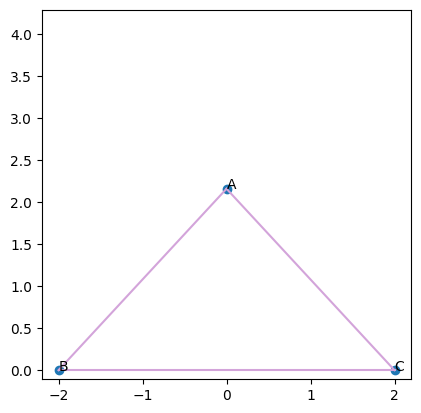

I0000 00:00:1767787629.156967      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5978 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1767787629.157222      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13824 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


INPUT INSTRUCTIONS:
sample (A B C) triangle ()
define D ((midp A B))
define E ((midp A C))
parameterize LDE (through-l D)
assert (on-line E LDE)
parameterize LBC (through-l B)
assert (on-line C LBC)
assert (para LBC LDE)


Sampling initializations...: 100%|██████████| 20/20 [00:02<00:00,  7.95it/s]


[     0]   0.104339298795 ||   0.100000
======== Print losses ==========
-- Losses --
  on-line_E_LDE                                      0.0183902773
  on-line_C_LBC                                      0.0856895845
  para_LBC_LDE                                       0.0002587921
  points                                             0.0000006443
  distinct                                           0.0000000006
-- Goals --
-- NDGs --


<Figure size 640x480 with 0 Axes>

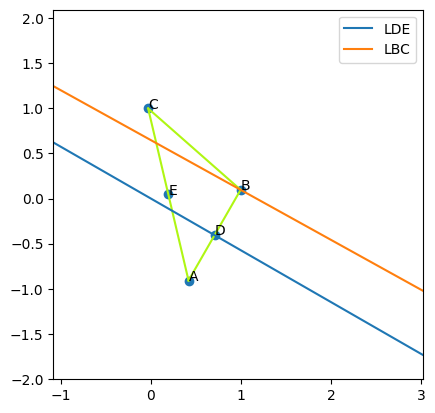

[     1]   0.160456401188 ||   0.099964
[     2]   0.134522841196 ||   0.099929
[     3]   0.059484661931 ||   0.099893
[     4]   0.006994160253 ||   0.099857
[     5]   0.056352241183 ||   0.099822
[     6]   0.078582726813 ||   0.099786
[     7]   0.047907618564 ||   0.099751
[     8]   0.020611952177 ||   0.099715
[     9]   0.014238612726 ||   0.099680
[    10]   0.014240182661 ||   0.099644
[    11]   0.013180461483 ||   0.099608
[    12]   0.014321072550 ||   0.099573
[    13]   0.018355014810 ||   0.099537
[    14]   0.019928000923 ||   0.099502
[    15]   0.015328610762 ||   0.099466
[    16]   0.007129262806 ||   0.099431
[    17]   0.001142102671 ||   0.099395
[    18]   0.000994924665 ||   0.099360
======== Print losses ==========
-- Losses --
  on-line_E_LDE                                      0.0003089539
  on-line_C_LBC                                      0.0006362213
  para_LBC_LDE                                       0.0000489778
  points                            

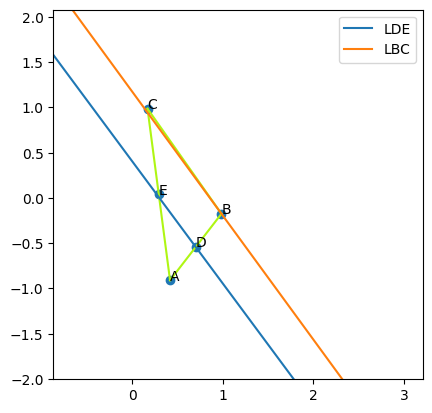

I0000 00:00:1767787634.844777      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5978 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1767787634.844966      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13824 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


INPUT INSTRUCTIONS:
sample (A B C) right-tri (B)
define D ((midp A B))
define E ((midp A C))
parameterize LDE (through-l D)
assert (on-line E LDE)
parameterize LBC (through-l B)
assert (on-line C LBC)
assert (para LBC LDE)
parameterize LAC (through-l A)
assert (perp LAC LDE)
assert (eq-n (uangle A D E) 90.0)


Sampling initializations...: 100%|██████████| 20/20 [00:02<00:00,  8.94it/s]


[     0] 7820.907837871947 ||   0.100000
======== Print losses ==========
-- Losses --
  on-line_E_LDE                                      0.8039500934
  on-line_C_LBC                                      0.0035891008
  para_LBC_LDE                                       0.2665420494
  perp_LAC_LDE                                       0.1096466844
  eq-n_(uangle A D E)_90.0                           7819.7241075802
  points                                             0.0000023638
  distinct                                           0.0000000000
-- Goals --
-- NDGs --


<Figure size 640x480 with 0 Axes>

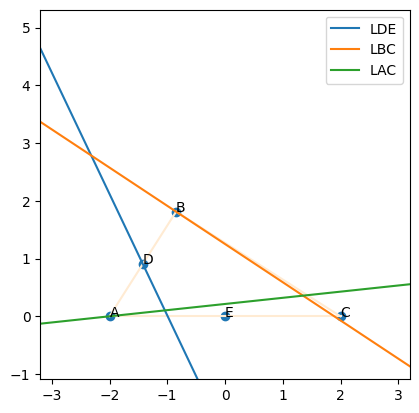

[     1] 7820.674608422610 ||   0.099964
[     2] 7820.382439986263 ||   0.099929
[     3] 7820.177629166175 ||   0.099893
[     4] 7820.059636766720 ||   0.099857
[     5] 7819.985823226674 ||   0.099822
[     6] 7819.945399575699 ||   0.099786
[     7] 7819.922511183431 ||   0.099751
[     8] 7819.893405667072 ||   0.099715
[     9] 7819.846810837941 ||   0.099680
[    10] 7819.791978344648 ||   0.099644
[    11] 7819.748545680398 ||   0.099608
[    12] 7819.729789571840 ||   0.099573
[    13] 7819.734207242704 ||   0.099537
[    14] 7819.750176471288 ||   0.099502
[    15] 7819.766774350282 ||   0.099466
[    16] 7819.779173412508 ||   0.099431
[    17] 7819.786400630119 ||   0.099395
[    18] 7819.787403016739 ||   0.099360
[    19] 7819.781234182426 ||   0.099325
[    20] 7819.769930181412 ||   0.099289
[    21] 7819.758297106386 ||   0.099254
[    22] 7819.750343533184 ||   0.099218
[    23] 7819.746618587983 ||   0.099183
[    24] 7819.745073220014 ||   0.099148
[    25] 7819.74

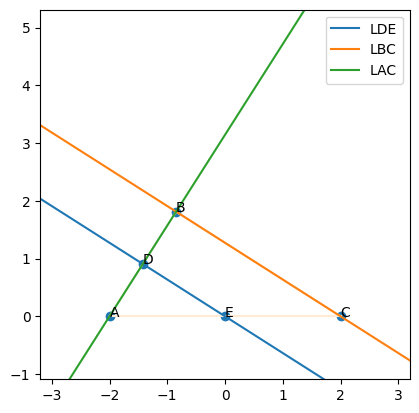

[  1001] 7819.724109943960 ||   0.069975
[  1002] 7819.724109943960 ||   0.069950
[  1003] 7819.724109943960 ||   0.069925
[  1004] 7819.724109943960 ||   0.069900
[  1005] 7819.724109943960 ||   0.069875
[  1006] 7819.724109943960 ||   0.069850
[  1007] 7819.724109943960 ||   0.069825
[  1008] 7819.724109943960 ||   0.069801
[  1009] 7819.724109943960 ||   0.069776
[  1010] 7819.724109943960 ||   0.069751
[  1011] 7819.724109943960 ||   0.069726
[  1012] 7819.724109943960 ||   0.069701
[  1013] 7819.724109943960 ||   0.069676
[  1014] 7819.724109943960 ||   0.069651
[  1015] 7819.724109943960 ||   0.069626
[  1016] 7819.724109943960 ||   0.069602
[  1017] 7819.724109943960 ||   0.069577
[  1018] 7819.724109943960 ||   0.069552
[  1019] 7819.724109943960 ||   0.069527
[  1020] 7819.724109943960 ||   0.069502
[  1021] 7819.724109943960 ||   0.069478
[  1022] 7819.724109943960 ||   0.069453
[  1023] 7819.724109943960 ||   0.069428
[  1024] 7819.724109943960 ||   0.069403
[  1025] 7819.72

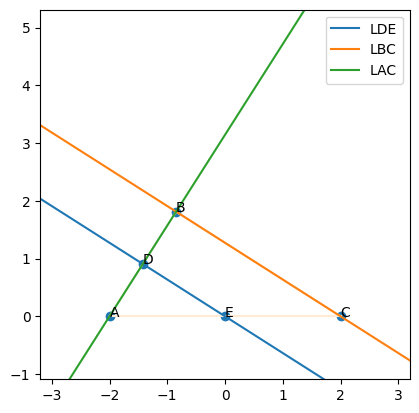

[  2001] 7819.724109943960 ||   0.048983
[  2002] 7819.724109943960 ||   0.048965
[  2003] 7819.724109943960 ||   0.048948
[  2004] 7819.724109943960 ||   0.048930
[  2005] 7819.724109943960 ||   0.048913
[  2006] 7819.724109943960 ||   0.048895
[  2007] 7819.724109943960 ||   0.048878
[  2008] 7819.724109943960 ||   0.048860
[  2009] 7819.724109943960 ||   0.048843
[  2010] 7819.724109943960 ||   0.048826
[  2011] 7819.724109943960 ||   0.048808
[  2012] 7819.724109943960 ||   0.048791
[  2013] 7819.724109943960 ||   0.048773
[  2014] 7819.724109943960 ||   0.048756
[  2015] 7819.724109943960 ||   0.048739
[  2016] 7819.724109943960 ||   0.048721
[  2017] 7819.724109943960 ||   0.048704
[  2018] 7819.724109943960 ||   0.048686
[  2019] 7819.724109943960 ||   0.048669
[  2020] 7819.724109943960 ||   0.048652
[  2021] 7819.724109943960 ||   0.048634
[  2022] 7819.724109943960 ||   0.048617
[  2023] 7819.724109943960 ||   0.048600
[  2024] 7819.724109943960 ||   0.048582
[  2025] 7819.72

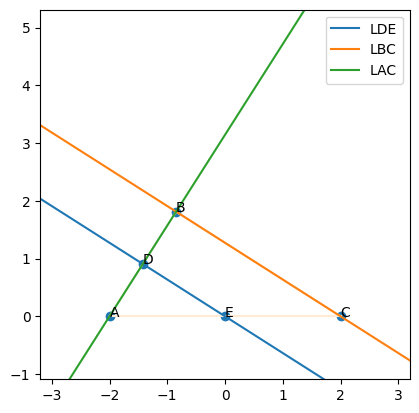

[  3001] 7819.724109943960 ||   0.034288
[  3002] 7819.724109943960 ||   0.034276
[  3003] 7819.724109943960 ||   0.034263
[  3004] 7819.724109943960 ||   0.034251
[  3005] 7819.724109943960 ||   0.034239
[  3006] 7819.724109943960 ||   0.034227
[  3007] 7819.724109943960 ||   0.034214
[  3008] 7819.724109943960 ||   0.034202
[  3009] 7819.724109943960 ||   0.034190
[  3010] 7819.724109943960 ||   0.034178
[  3011] 7819.724109943960 ||   0.034166
[  3012] 7819.724109943960 ||   0.034154
[  3013] 7819.724109943960 ||   0.034141
[  3014] 7819.724109943960 ||   0.034129
[  3015] 7819.724109943960 ||   0.034117
[  3016] 7819.724109943960 ||   0.034105
[  3017] 7819.724109943960 ||   0.034093
[  3018] 7819.724109943960 ||   0.034080
[  3019] 7819.724109943960 ||   0.034068
[  3020] 7819.724109943960 ||   0.034056
[  3021] 7819.724109943960 ||   0.034044
[  3022] 7819.724109943960 ||   0.034032
[  3023] 7819.724109943960 ||   0.034020
[  3024] 7819.724109943960 ||   0.034008
[  3025] 7819.72

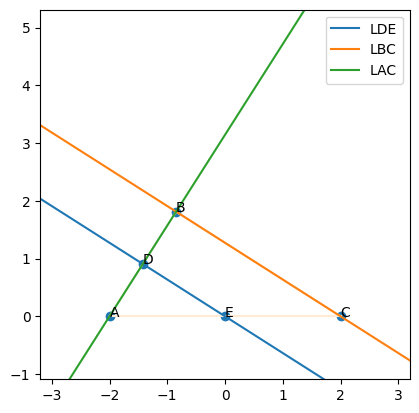

[  4001] 7819.724109943960 ||   0.024001
[  4002] 7819.724109943960 ||   0.023993
[  4003] 7819.724109943960 ||   0.023984
[  4004] 7819.724109943960 ||   0.023976
[  4005] 7819.724109943960 ||   0.023967
[  4006] 7819.724109943960 ||   0.023959
[  4007] 7819.724109943960 ||   0.023950
[  4008] 7819.724109943960 ||   0.023942
[  4009] 7819.724109943960 ||   0.023933
[  4010] 7819.724109943960 ||   0.023925
[  4011] 7819.724109943960 ||   0.023916
[  4012] 7819.724109943960 ||   0.023907
[  4013] 7819.724109943960 ||   0.023899
[  4014] 7819.724109943960 ||   0.023890
[  4015] 7819.724109943960 ||   0.023882
[  4016] 7819.724109943960 ||   0.023873
[  4017] 7819.724109943960 ||   0.023865
[  4018] 7819.724109943960 ||   0.023856
[  4019] 7819.724109943960 ||   0.023848
[  4020] 7819.724109943960 ||   0.023839
[  4021] 7819.724109943960 ||   0.023831
[  4022] 7819.724109943960 ||   0.023822
[  4023] 7819.724109943960 ||   0.023814
[  4024] 7819.724109943960 ||   0.023805
[  4025] 7819.72

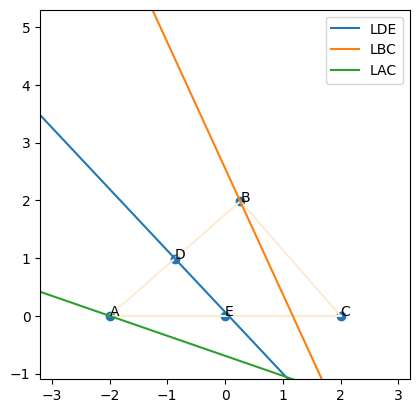

[     1] 7820.699103552951 ||   0.099964
[     2] 7820.367452377583 ||   0.099929
[     3] 7820.210206955399 ||   0.099893
[     4] 7820.198677584420 ||   0.099857
[     5] 7820.236861442112 ||   0.099822
[     6] 7820.242675930674 ||   0.099786
[     7] 7820.201297367660 ||   0.099751
[     8] 7820.130160359475 ||   0.099715
[     9] 7820.051630432526 ||   0.099680
[    10] 7819.983484417922 ||   0.099644
[    11] 7819.935515623044 ||   0.099608
[    12] 7819.908905492428 ||   0.099573
[    13] 7819.898030627481 ||   0.099537
[    14] 7819.894055346168 ||   0.099502
[    15] 7819.888723708696 ||   0.099466
[    16] 7819.876835823211 ||   0.099431
[    17] 7819.856948033732 ||   0.099395
[    18] 7819.830777194618 ||   0.099360
[    19] 7819.802004700578 ||   0.099325
[    20] 7819.774947100854 ||   0.099289
[    21] 7819.753335378949 ||   0.099254
[    22] 7819.739378008888 ||   0.099218
[    23] 7819.733290506638 ||   0.099183
[    24] 7819.733428772022 ||   0.099148
[    25] 7819.73

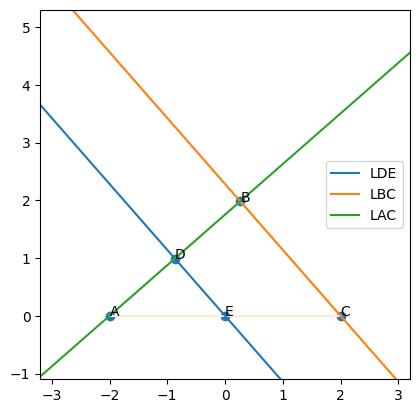

[  1001] 7819.724109722192 ||   0.069975
[  1002] 7819.724109722192 ||   0.069950
[  1003] 7819.724109722192 ||   0.069925
[  1004] 7819.724109722192 ||   0.069900
[  1005] 7819.724109722192 ||   0.069875
[  1006] 7819.724109722192 ||   0.069850
[  1007] 7819.724109722192 ||   0.069825
[  1008] 7819.724109722192 ||   0.069801
[  1009] 7819.724109722192 ||   0.069776
[  1010] 7819.724109722192 ||   0.069751
[  1011] 7819.724109722192 ||   0.069726
[  1012] 7819.724109722192 ||   0.069701
[  1013] 7819.724109722192 ||   0.069676
[  1014] 7819.724109722192 ||   0.069651
[  1015] 7819.724109722192 ||   0.069626
[  1016] 7819.724109722192 ||   0.069602
[  1017] 7819.724109722192 ||   0.069577
[  1018] 7819.724109722192 ||   0.069552
[  1019] 7819.724109722192 ||   0.069527
[  1020] 7819.724109722192 ||   0.069502
[  1021] 7819.724109722192 ||   0.069478
[  1022] 7819.724109722192 ||   0.069453
[  1023] 7819.724109722192 ||   0.069428
[  1024] 7819.724109722192 ||   0.069403
[  1025] 7819.72

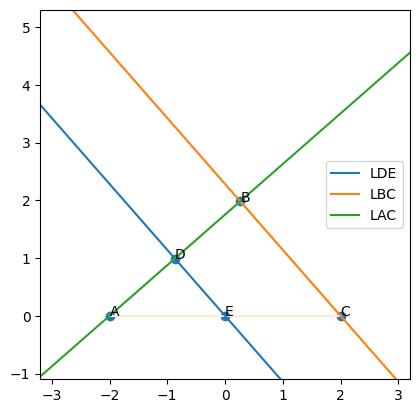

[  2001] 7819.724109722192 ||   0.048983
[  2002] 7819.724109722192 ||   0.048965
[  2003] 7819.724109722192 ||   0.048948
[  2004] 7819.724109722192 ||   0.048930
[  2005] 7819.724109722192 ||   0.048913
[  2006] 7819.724109722192 ||   0.048895
[  2007] 7819.724109722192 ||   0.048878
[  2008] 7819.724109722192 ||   0.048860
[  2009] 7819.724109722192 ||   0.048843
[  2010] 7819.724109722192 ||   0.048826
[  2011] 7819.724109722192 ||   0.048808
[  2012] 7819.724109722192 ||   0.048791
[  2013] 7819.724109722192 ||   0.048773
[  2014] 7819.724109722192 ||   0.048756
[  2015] 7819.724109722192 ||   0.048739
[  2016] 7819.724109722192 ||   0.048721
[  2017] 7819.724109722192 ||   0.048704
[  2018] 7819.724109722192 ||   0.048686
[  2019] 7819.724109722192 ||   0.048669
[  2020] 7819.724109722192 ||   0.048652
[  2021] 7819.724109722192 ||   0.048634
[  2022] 7819.724109722192 ||   0.048617
[  2023] 7819.724109722192 ||   0.048600
[  2024] 7819.724109722192 ||   0.048582
[  2025] 7819.72

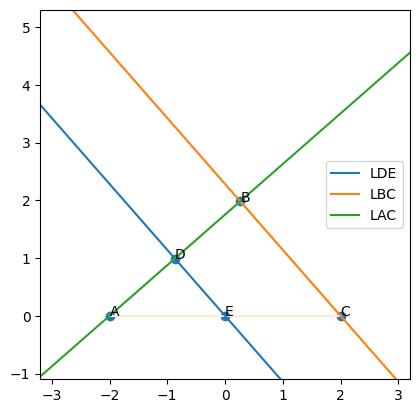

[  3001] 7819.724109722192 ||   0.034288
[  3002] 7819.724109722192 ||   0.034276
[  3003] 7819.724109722192 ||   0.034263
[  3004] 7819.724109722192 ||   0.034251
[  3005] 7819.724109722192 ||   0.034239
[  3006] 7819.724109722192 ||   0.034227
[  3007] 7819.724109722192 ||   0.034214
[  3008] 7819.724109722192 ||   0.034202
[  3009] 7819.724109722192 ||   0.034190
[  3010] 7819.724109722192 ||   0.034178
[  3011] 7819.724109722192 ||   0.034166
[  3012] 7819.724109722192 ||   0.034154
[  3013] 7819.724109722192 ||   0.034141
[  3014] 7819.724109722192 ||   0.034129
[  3015] 7819.724109722192 ||   0.034117
[  3016] 7819.724109722192 ||   0.034105
[  3017] 7819.724109722192 ||   0.034093
[  3018] 7819.724109722192 ||   0.034080
[  3019] 7819.724109722192 ||   0.034068
[  3020] 7819.724109722192 ||   0.034056
[  3021] 7819.724109722192 ||   0.034044
[  3022] 7819.724109722192 ||   0.034032
[  3023] 7819.724109722192 ||   0.034020
[  3024] 7819.724109722192 ||   0.034008
[  3025] 7819.72

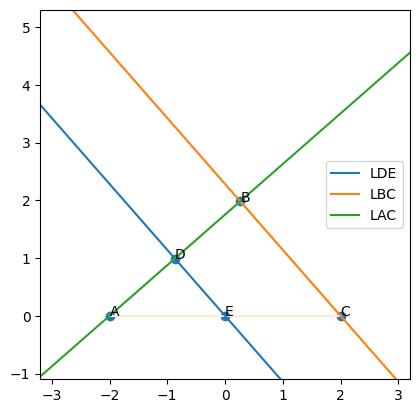

[  4001] 7819.724109722192 ||   0.024001
[  4002] 7819.724109722192 ||   0.023993
[  4003] 7819.724109722192 ||   0.023984
[  4004] 7819.724109722192 ||   0.023976
[  4005] 7819.724109722192 ||   0.023967
[  4006] 7819.724109722192 ||   0.023959
[  4007] 7819.724109722192 ||   0.023950
[  4008] 7819.724109722192 ||   0.023942
[  4009] 7819.724109722192 ||   0.023933
[  4010] 7819.724109722192 ||   0.023925
[  4011] 7819.724109722192 ||   0.023916
[  4012] 7819.724109722192 ||   0.023907
[  4013] 7819.724109722192 ||   0.023899
[  4014] 7819.724109722192 ||   0.023890
[  4015] 7819.724109722192 ||   0.023882
[  4016] 7819.724109722192 ||   0.023873
[  4017] 7819.724109722192 ||   0.023865
[  4018] 7819.724109722192 ||   0.023856
[  4019] 7819.724109722192 ||   0.023848
[  4020] 7819.724109722192 ||   0.023839
[  4021] 7819.724109722192 ||   0.023831
[  4022] 7819.724109722192 ||   0.023822
[  4023] 7819.724109722192 ||   0.023814
[  4024] 7819.724109722192 ||   0.023805
[  4025] 7819.72

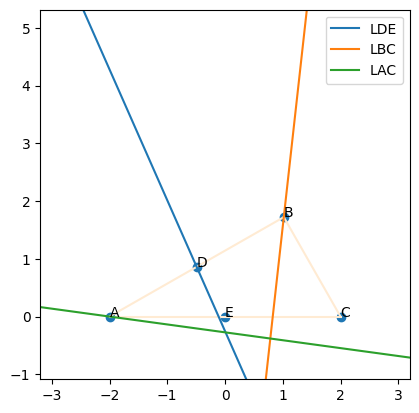

[     1] 7821.290966482570 ||   0.099964
[     2] 7821.042863292848 ||   0.099929
[     3] 7820.867231853408 ||   0.099893
[     4] 7820.745653781428 ||   0.099857
[     5] 7820.656560885557 ||   0.099822
[     6] 7820.581026626975 ||   0.099786
[     7] 7820.507027543978 ||   0.099751
[     8] 7820.429510586250 ||   0.099715
[     9] 7820.347925349496 ||   0.099680
[    10] 7820.263930763104 ||   0.099644
[    11] 7820.180045982266 ||   0.099608
[    12] 7820.098988289456 ||   0.099573
[    13] 7820.023368857047 ||   0.099537
[    14] 7819.955543523110 ||   0.099502
[    15] 7819.897509084368 ||   0.099466
[    16] 7819.850791381620 ||   0.099431
[    17] 7819.816297845187 ||   0.099395
[    18] 7819.794126404991 ||   0.099360
[    19] 7819.783340969931 ||   0.099325
[    20] 7819.781778388817 ||   0.099289
[    21] 7819.786065919337 ||   0.099254
[    22] 7819.792111691131 ||   0.099218
[    23] 7819.796100192454 ||   0.099183
[    24] 7819.795513820571 ||   0.099148
[    25] 7819.78

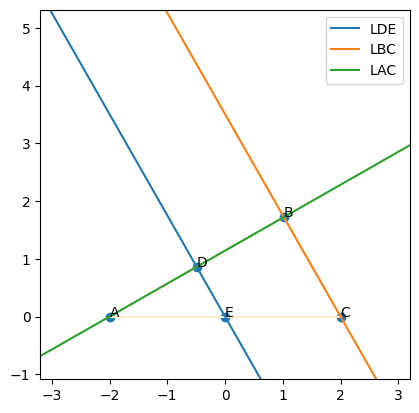

[  1001] 7819.724109535203 ||   0.069975
[  1002] 7819.724109535203 ||   0.069950
[  1003] 7819.724109535203 ||   0.069925
[  1004] 7819.724109535203 ||   0.069900
[  1005] 7819.724109535203 ||   0.069875
[  1006] 7819.724109535203 ||   0.069850
[  1007] 7819.724109535203 ||   0.069825
[  1008] 7819.724109535203 ||   0.069801
[  1009] 7819.724109535203 ||   0.069776
[  1010] 7819.724109535203 ||   0.069751
[  1011] 7819.724109535203 ||   0.069726
[  1012] 7819.724109535203 ||   0.069701
[  1013] 7819.724109535203 ||   0.069676
[  1014] 7819.724109535203 ||   0.069651
[  1015] 7819.724109535203 ||   0.069626
[  1016] 7819.724109535203 ||   0.069602
[  1017] 7819.724109535203 ||   0.069577
[  1018] 7819.724109535203 ||   0.069552
[  1019] 7819.724109535203 ||   0.069527
[  1020] 7819.724109535203 ||   0.069502
[  1021] 7819.724109535203 ||   0.069478
[  1022] 7819.724109535203 ||   0.069453
[  1023] 7819.724109535203 ||   0.069428
[  1024] 7819.724109535203 ||   0.069403
[  1025] 7819.72

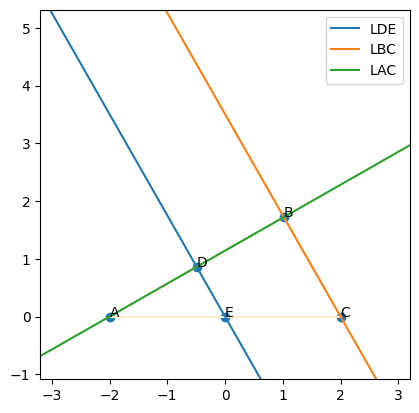

[  2001] 7819.724109535203 ||   0.048983
[  2002] 7819.724109535203 ||   0.048965
[  2003] 7819.724109535203 ||   0.048948
[  2004] 7819.724109535203 ||   0.048930
[  2005] 7819.724109535203 ||   0.048913
[  2006] 7819.724109535203 ||   0.048895
[  2007] 7819.724109535203 ||   0.048878
[  2008] 7819.724109535203 ||   0.048860
[  2009] 7819.724109535203 ||   0.048843
[  2010] 7819.724109535203 ||   0.048826
[  2011] 7819.724109535203 ||   0.048808
[  2012] 7819.724109535203 ||   0.048791
[  2013] 7819.724109535203 ||   0.048773
[  2014] 7819.724109535203 ||   0.048756
[  2015] 7819.724109535203 ||   0.048739
[  2016] 7819.724109535203 ||   0.048721
[  2017] 7819.724109535203 ||   0.048704
[  2018] 7819.724109535203 ||   0.048686
[  2019] 7819.724109535203 ||   0.048669
[  2020] 7819.724109535203 ||   0.048652
[  2021] 7819.724109535203 ||   0.048634
[  2022] 7819.724109535203 ||   0.048617
[  2023] 7819.724109535203 ||   0.048600
[  2024] 7819.724109535203 ||   0.048582
[  2025] 7819.72

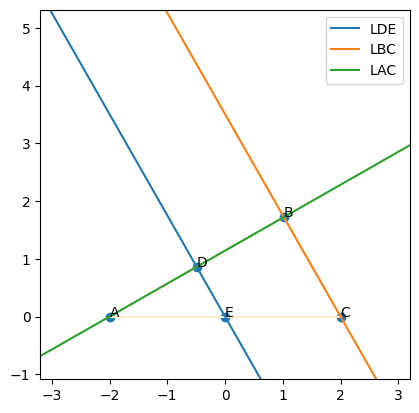

[  3001] 7819.724109535203 ||   0.034288
[  3002] 7819.724109535203 ||   0.034276
[  3003] 7819.724109535203 ||   0.034263
[  3004] 7819.724109535203 ||   0.034251
[  3005] 7819.724109535203 ||   0.034239
[  3006] 7819.724109535203 ||   0.034227
[  3007] 7819.724109535203 ||   0.034214
[  3008] 7819.724109535203 ||   0.034202
[  3009] 7819.724109535203 ||   0.034190
[  3010] 7819.724109535203 ||   0.034178
[  3011] 7819.724109535203 ||   0.034166
[  3012] 7819.724109535203 ||   0.034154
[  3013] 7819.724109535203 ||   0.034141
[  3014] 7819.724109535203 ||   0.034129
[  3015] 7819.724109535203 ||   0.034117
[  3016] 7819.724109535203 ||   0.034105
[  3017] 7819.724109535203 ||   0.034093
[  3018] 7819.724109535203 ||   0.034080
[  3019] 7819.724109535203 ||   0.034068
[  3020] 7819.724109535203 ||   0.034056
[  3021] 7819.724109535203 ||   0.034044
[  3022] 7819.724109535203 ||   0.034032
[  3023] 7819.724109535203 ||   0.034020
[  3024] 7819.724109535203 ||   0.034008
[  3025] 7819.72

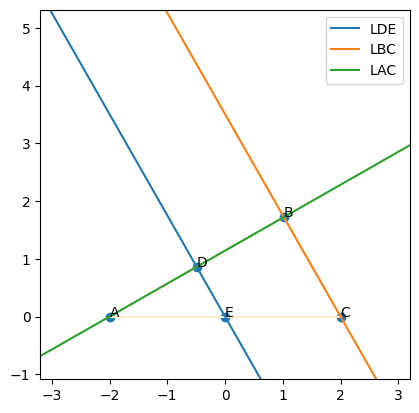

[  4001] 7819.724109535203 ||   0.024001
[  4002] 7819.724109535203 ||   0.023993
[  4003] 7819.724109535203 ||   0.023984
[  4004] 7819.724109535203 ||   0.023976
[  4005] 7819.724109535203 ||   0.023967
[  4006] 7819.724109535203 ||   0.023959
[  4007] 7819.724109535203 ||   0.023950
[  4008] 7819.724109535203 ||   0.023942
[  4009] 7819.724109535203 ||   0.023933
[  4010] 7819.724109535203 ||   0.023925
[  4011] 7819.724109535203 ||   0.023916
[  4012] 7819.724109535203 ||   0.023907
[  4013] 7819.724109535203 ||   0.023899
[  4014] 7819.724109535203 ||   0.023890
[  4015] 7819.724109535203 ||   0.023882
[  4016] 7819.724109535203 ||   0.023873
[  4017] 7819.724109535203 ||   0.023865
[  4018] 7819.724109535203 ||   0.023856
[  4019] 7819.724109535203 ||   0.023848
[  4020] 7819.724109535203 ||   0.023839
[  4021] 7819.724109535203 ||   0.023831
[  4022] 7819.724109535203 ||   0.023822
[  4023] 7819.724109535203 ||   0.023814
[  4024] 7819.724109535203 ||   0.023805
[  4025] 7819.72

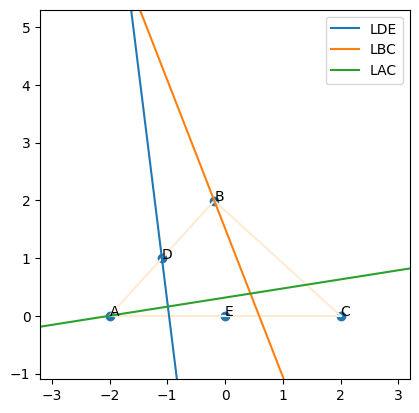

[     1] 7821.925486024027 ||   0.099964
[     2] 7821.435137798766 ||   0.099929
[     3] 7820.979831459241 ||   0.099893
[     4] 7820.580171759734 ||   0.099857
[     5] 7820.256673498071 ||   0.099822
[     6] 7820.026219997070 ||   0.099786
[     7] 7819.896469317686 ||   0.099751
[     8] 7819.857773890678 ||   0.099715
[     9] 7819.876735082147 ||   0.099680
[    10] 7819.910875649866 ||   0.099644
[    11] 7819.934323224684 ||   0.099608
[    12] 7819.939745215045 ||   0.099573
[    13] 7819.930494539520 ||   0.099537
[    14] 7819.913813824292 ||   0.099502
[    15] 7819.895401415518 ||   0.099466
[    16] 7819.876734611305 ||   0.099431
[    17] 7819.856291792378 ||   0.099395
[    18] 7819.833208372969 ||   0.099360
[    19] 7819.809267617519 ||   0.099325
[    20] 7819.787875690685 ||   0.099289
[    21] 7819.772144627073 ||   0.099254
[    22] 7819.763618469373 ||   0.099218
[    23] 7819.761877519002 ||   0.099183
[    24] 7819.764852187904 ||   0.099148
[    25] 7819.76

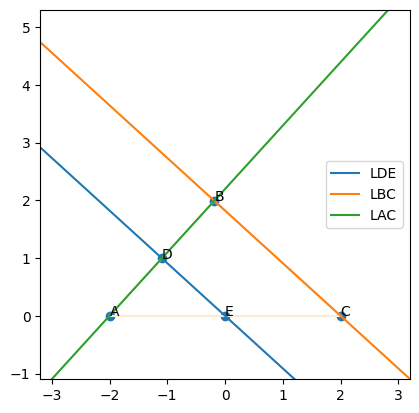

[  1001] 7819.724109817209 ||   0.069975
[  1002] 7819.724109817209 ||   0.069950
[  1003] 7819.724109817209 ||   0.069925
[  1004] 7819.724109817209 ||   0.069900
[  1005] 7819.724109817209 ||   0.069875
[  1006] 7819.724109817209 ||   0.069850
[  1007] 7819.724109817209 ||   0.069825
[  1008] 7819.724109817209 ||   0.069801
[  1009] 7819.724109817209 ||   0.069776
[  1010] 7819.724109817209 ||   0.069751
[  1011] 7819.724109817209 ||   0.069726
[  1012] 7819.724109817209 ||   0.069701
[  1013] 7819.724109817209 ||   0.069676
[  1014] 7819.724109817209 ||   0.069651
[  1015] 7819.724109817209 ||   0.069626
[  1016] 7819.724109817209 ||   0.069602
[  1017] 7819.724109817209 ||   0.069577
[  1018] 7819.724109817209 ||   0.069552
[  1019] 7819.724109817209 ||   0.069527
[  1020] 7819.724109817209 ||   0.069502
[  1021] 7819.724109817209 ||   0.069478
[  1022] 7819.724109817209 ||   0.069453
[  1023] 7819.724109817209 ||   0.069428
[  1024] 7819.724109817209 ||   0.069403
[  1025] 7819.72

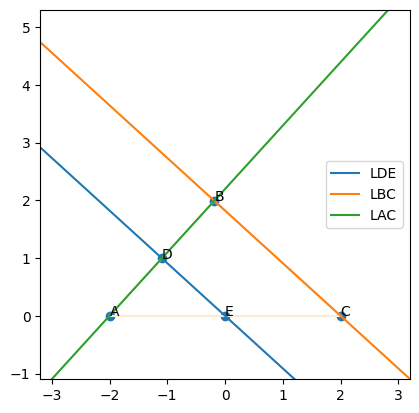

[  2001] 7819.724109817209 ||   0.048983
[  2002] 7819.724109817209 ||   0.048965
[  2003] 7819.724109817209 ||   0.048948
[  2004] 7819.724109817209 ||   0.048930
[  2005] 7819.724109817209 ||   0.048913
[  2006] 7819.724109817209 ||   0.048895
[  2007] 7819.724109817209 ||   0.048878
[  2008] 7819.724109817209 ||   0.048860
[  2009] 7819.724109817209 ||   0.048843
[  2010] 7819.724109817209 ||   0.048826
[  2011] 7819.724109817209 ||   0.048808
[  2012] 7819.724109817209 ||   0.048791
[  2013] 7819.724109817209 ||   0.048773
[  2014] 7819.724109817209 ||   0.048756
[  2015] 7819.724109817209 ||   0.048739
[  2016] 7819.724109817209 ||   0.048721
[  2017] 7819.724109817209 ||   0.048704
[  2018] 7819.724109817209 ||   0.048686
[  2019] 7819.724109817209 ||   0.048669
[  2020] 7819.724109817209 ||   0.048652
[  2021] 7819.724109817209 ||   0.048634
[  2022] 7819.724109817209 ||   0.048617
[  2023] 7819.724109817209 ||   0.048600
[  2024] 7819.724109817209 ||   0.048582
[  2025] 7819.72

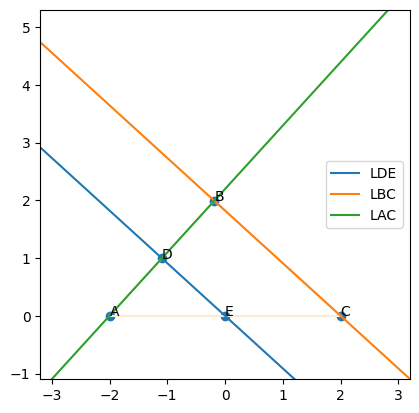

[  3001] 7819.724109817209 ||   0.034288
[  3002] 7819.724109817209 ||   0.034276
[  3003] 7819.724109817209 ||   0.034263
[  3004] 7819.724109817209 ||   0.034251
[  3005] 7819.724109817209 ||   0.034239
[  3006] 7819.724109817209 ||   0.034227
[  3007] 7819.724109817209 ||   0.034214
[  3008] 7819.724109817209 ||   0.034202
[  3009] 7819.724109817209 ||   0.034190
[  3010] 7819.724109817209 ||   0.034178
[  3011] 7819.724109817209 ||   0.034166
[  3012] 7819.724109817209 ||   0.034154
[  3013] 7819.724109817209 ||   0.034141
[  3014] 7819.724109817209 ||   0.034129
[  3015] 7819.724109817209 ||   0.034117
[  3016] 7819.724109817209 ||   0.034105
[  3017] 7819.724109817209 ||   0.034093
[  3018] 7819.724109817209 ||   0.034080
[  3019] 7819.724109817209 ||   0.034068
[  3020] 7819.724109817209 ||   0.034056
[  3021] 7819.724109817209 ||   0.034044
[  3022] 7819.724109817209 ||   0.034032
[  3023] 7819.724109817209 ||   0.034020
[  3024] 7819.724109817209 ||   0.034008
[  3025] 7819.72

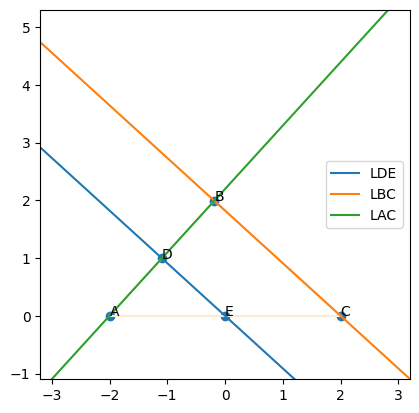

[  4001] 7819.724109817209 ||   0.024001
[  4002] 7819.724109817209 ||   0.023993
[  4003] 7819.724109817209 ||   0.023984
[  4004] 7819.724109817209 ||   0.023976
[  4005] 7819.724109817209 ||   0.023967
[  4006] 7819.724109817209 ||   0.023959
[  4007] 7819.724109817209 ||   0.023950
[  4008] 7819.724109817209 ||   0.023942
[  4009] 7819.724109817209 ||   0.023933
[  4010] 7819.724109817209 ||   0.023925
[  4011] 7819.724109817209 ||   0.023916
[  4012] 7819.724109817209 ||   0.023907
[  4013] 7819.724109817209 ||   0.023899
[  4014] 7819.724109817209 ||   0.023890
[  4015] 7819.724109817209 ||   0.023882
[  4016] 7819.724109817209 ||   0.023873
[  4017] 7819.724109817209 ||   0.023865
[  4018] 7819.724109817209 ||   0.023856
[  4019] 7819.724109817209 ||   0.023848
[  4020] 7819.724109817209 ||   0.023839
[  4021] 7819.724109817209 ||   0.023831
[  4022] 7819.724109817209 ||   0.023822
[  4023] 7819.724109817209 ||   0.023814
[  4024] 7819.724109817209 ||   0.023805
[  4025] 7819.72

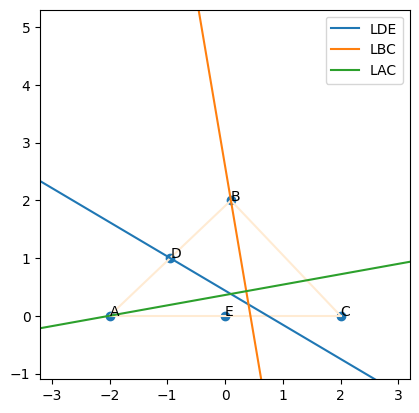

[     1] 7822.653433525627 ||   0.099964
[     2] 7821.931327400711 ||   0.099929
[     3] 7821.265413192804 ||   0.099893
[     4] 7820.704536903927 ||   0.099857
[     5] 7820.290375976062 ||   0.099822
[     6] 7820.041413481321 ||   0.099786
[     7] 7819.938913758219 ||   0.099751
[     8] 7819.936644997144 ||   0.099715
[     9] 7819.991191878961 ||   0.099680
[    10] 7820.064840933841 ||   0.099644
[    11] 7820.120593123282 ||   0.099608
[    12] 7820.135128401434 ||   0.099573
[    13] 7820.106979711931 ||   0.099537
[    14] 7820.049001594849 ||   0.099502
[    15] 7819.978044222215 ||   0.099466
[    16] 7819.908834474061 ||   0.099431
[    17] 7819.851461221656 ||   0.099395
[    18] 7819.810899200841 ||   0.099360
[    19] 7819.787639188688 ||   0.099325
[    20] 7819.778904350418 ||   0.099289
[    21] 7819.780093592213 ||   0.099254
[    22] 7819.786160407408 ||   0.099218
[    23] 7819.792702387635 ||   0.099183
[    24] 7819.796637270023 ||   0.099148
[    25] 7819.79

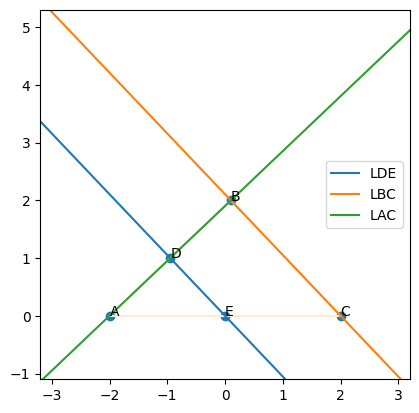

[  1001] 7819.724109757458 ||   0.069975
[  1002] 7819.724109757458 ||   0.069950
[  1003] 7819.724109757458 ||   0.069925
[  1004] 7819.724109757458 ||   0.069900
[  1005] 7819.724109757458 ||   0.069875
[  1006] 7819.724109757458 ||   0.069850
[  1007] 7819.724109757458 ||   0.069825
[  1008] 7819.724109757458 ||   0.069801
[  1009] 7819.724109757458 ||   0.069776
[  1010] 7819.724109757458 ||   0.069751
[  1011] 7819.724109757458 ||   0.069726
[  1012] 7819.724109757458 ||   0.069701
[  1013] 7819.724109757458 ||   0.069676
[  1014] 7819.724109757458 ||   0.069651
[  1015] 7819.724109757458 ||   0.069626
[  1016] 7819.724109757458 ||   0.069602
[  1017] 7819.724109757458 ||   0.069577
[  1018] 7819.724109757458 ||   0.069552
[  1019] 7819.724109757458 ||   0.069527
[  1020] 7819.724109757458 ||   0.069502
[  1021] 7819.724109757458 ||   0.069478
[  1022] 7819.724109757458 ||   0.069453
[  1023] 7819.724109757458 ||   0.069428
[  1024] 7819.724109757458 ||   0.069403
[  1025] 7819.72

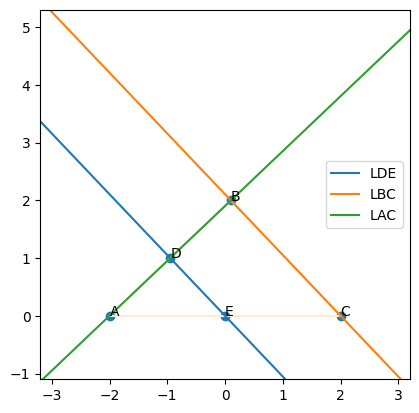

[  2001] 7819.724109757458 ||   0.048983
[  2002] 7819.724109757458 ||   0.048965
[  2003] 7819.724109757458 ||   0.048948
[  2004] 7819.724109757458 ||   0.048930
[  2005] 7819.724109757458 ||   0.048913
[  2006] 7819.724109757458 ||   0.048895
[  2007] 7819.724109757458 ||   0.048878
[  2008] 7819.724109757458 ||   0.048860
[  2009] 7819.724109757458 ||   0.048843
[  2010] 7819.724109757458 ||   0.048826
[  2011] 7819.724109757458 ||   0.048808
[  2012] 7819.724109757458 ||   0.048791
[  2013] 7819.724109757458 ||   0.048773
[  2014] 7819.724109757458 ||   0.048756
[  2015] 7819.724109757458 ||   0.048739
[  2016] 7819.724109757458 ||   0.048721
[  2017] 7819.724109757458 ||   0.048704
[  2018] 7819.724109757458 ||   0.048686
[  2019] 7819.724109757458 ||   0.048669
[  2020] 7819.724109757458 ||   0.048652
[  2021] 7819.724109757458 ||   0.048634
[  2022] 7819.724109757458 ||   0.048617
[  2023] 7819.724109757458 ||   0.048600
[  2024] 7819.724109757458 ||   0.048582
[  2025] 7819.72

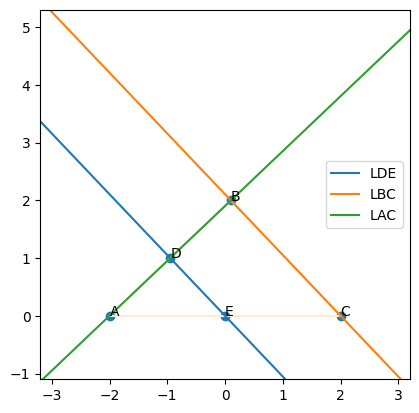

[  3001] 7819.724109757458 ||   0.034288
[  3002] 7819.724109757458 ||   0.034276
[  3003] 7819.724109757458 ||   0.034263
[  3004] 7819.724109757458 ||   0.034251
[  3005] 7819.724109757458 ||   0.034239
[  3006] 7819.724109757458 ||   0.034227
[  3007] 7819.724109757458 ||   0.034214
[  3008] 7819.724109757458 ||   0.034202
[  3009] 7819.724109757458 ||   0.034190
[  3010] 7819.724109757458 ||   0.034178
[  3011] 7819.724109757458 ||   0.034166
[  3012] 7819.724109757458 ||   0.034154
[  3013] 7819.724109757458 ||   0.034141
[  3014] 7819.724109757458 ||   0.034129
[  3015] 7819.724109757458 ||   0.034117
[  3016] 7819.724109757458 ||   0.034105
[  3017] 7819.724109757458 ||   0.034093
[  3018] 7819.724109757458 ||   0.034080
[  3019] 7819.724109757458 ||   0.034068
[  3020] 7819.724109757458 ||   0.034056
[  3021] 7819.724109757458 ||   0.034044
[  3022] 7819.724109757458 ||   0.034032
[  3023] 7819.724109757458 ||   0.034020
[  3024] 7819.724109757458 ||   0.034008
[  3025] 7819.72

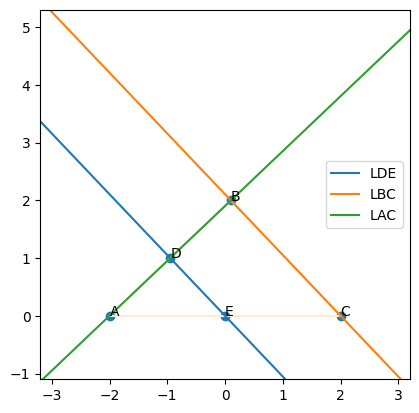

[  4001] 7819.724109757458 ||   0.024001
[  4002] 7819.724109757458 ||   0.023993
[  4003] 7819.724109757458 ||   0.023984
[  4004] 7819.724109757458 ||   0.023976
[  4005] 7819.724109757458 ||   0.023967
[  4006] 7819.724109757458 ||   0.023959
[  4007] 7819.724109757458 ||   0.023950
[  4008] 7819.724109757458 ||   0.023942
[  4009] 7819.724109757458 ||   0.023933
[  4010] 7819.724109757458 ||   0.023925
[  4011] 7819.724109757458 ||   0.023916
[  4012] 7819.724109757458 ||   0.023907
[  4013] 7819.724109757458 ||   0.023899
[  4014] 7819.724109757458 ||   0.023890
[  4015] 7819.724109757458 ||   0.023882
[  4016] 7819.724109757458 ||   0.023873
[  4017] 7819.724109757458 ||   0.023865
[  4018] 7819.724109757458 ||   0.023856
[  4019] 7819.724109757458 ||   0.023848
[  4020] 7819.724109757458 ||   0.023839
[  4021] 7819.724109757458 ||   0.023831
[  4022] 7819.724109757458 ||   0.023822
[  4023] 7819.724109757458 ||   0.023814
[  4024] 7819.724109757458 ||   0.023805
[  4025] 7819.72

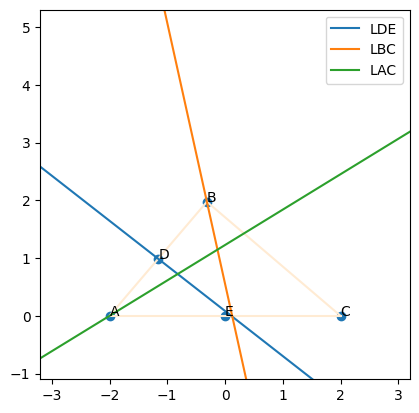

[     1] 7822.731980541447 ||   0.099964
[     2] 7822.141876954533 ||   0.099929
[     3] 7821.597497235255 ||   0.099893
[     4] 7821.011826047184 ||   0.099857
[     5] 7820.472076446888 ||   0.099822
[     6] 7820.061297470083 ||   0.099786
[     7] 7819.824889421438 ||   0.099751
[     8] 7819.758203318384 ||   0.099715
[     9] 7819.814817472085 ||   0.099680
[    10] 7819.928999502360 ||   0.099644
[    11] 7820.038793353078 ||   0.099608
[    12] 7820.107051060776 ||   0.099573
[    13] 7820.126419394529 ||   0.099537
[    14] 7820.106793252128 ||   0.099502
[    15] 7820.061862086790 ||   0.099466
[    16] 7820.002892358487 ||   0.099431
[    17] 7819.938301551643 ||   0.099395
[    18] 7819.875249195017 ||   0.099360
[    19] 7819.820358093485 ||   0.099325
[    20] 7819.778882559702 ||   0.099289
[    21] 7819.753359424205 ||   0.099254
[    22] 7819.742959170535 ||   0.099218
[    23] 7819.744043142137 ||   0.099183
[    24] 7819.751655926527 ||   0.099148
[    25] 7819.76

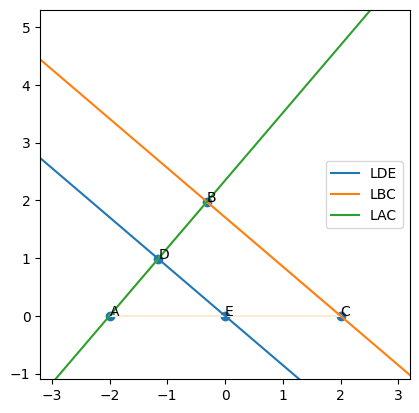

[  1001] 7819.724109842906 ||   0.069975
[  1002] 7819.724109842906 ||   0.069950
[  1003] 7819.724109842906 ||   0.069925
[  1004] 7819.724109842906 ||   0.069900
[  1005] 7819.724109842906 ||   0.069875
[  1006] 7819.724109842906 ||   0.069850
[  1007] 7819.724109842906 ||   0.069825
[  1008] 7819.724109842906 ||   0.069801
[  1009] 7819.724109842906 ||   0.069776
[  1010] 7819.724109842906 ||   0.069751
[  1011] 7819.724109842906 ||   0.069726
[  1012] 7819.724109842906 ||   0.069701
[  1013] 7819.724109842906 ||   0.069676
[  1014] 7819.724109842906 ||   0.069651
[  1015] 7819.724109842906 ||   0.069626
[  1016] 7819.724109842906 ||   0.069602
[  1017] 7819.724109842906 ||   0.069577
[  1018] 7819.724109842906 ||   0.069552
[  1019] 7819.724109842906 ||   0.069527
[  1020] 7819.724109842906 ||   0.069502
[  1021] 7819.724109842906 ||   0.069478
[  1022] 7819.724109842906 ||   0.069453
[  1023] 7819.724109842906 ||   0.069428
[  1024] 7819.724109842906 ||   0.069403
[  1025] 7819.72

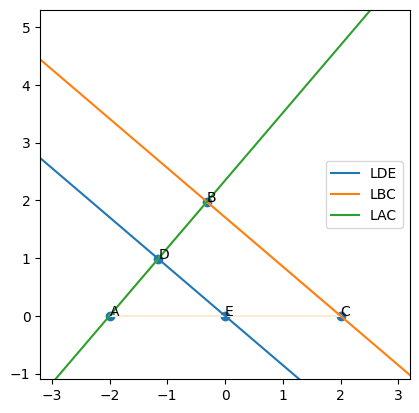

[  2001] 7819.724109842906 ||   0.048983
[  2002] 7819.724109842906 ||   0.048965
[  2003] 7819.724109842906 ||   0.048948
[  2004] 7819.724109842906 ||   0.048930
[  2005] 7819.724109842906 ||   0.048913
[  2006] 7819.724109842906 ||   0.048895
[  2007] 7819.724109842906 ||   0.048878
[  2008] 7819.724109842906 ||   0.048860
[  2009] 7819.724109842906 ||   0.048843
[  2010] 7819.724109842906 ||   0.048826
[  2011] 7819.724109842906 ||   0.048808
[  2012] 7819.724109842906 ||   0.048791
[  2013] 7819.724109842906 ||   0.048773
[  2014] 7819.724109842906 ||   0.048756
[  2015] 7819.724109842906 ||   0.048739
[  2016] 7819.724109842906 ||   0.048721
[  2017] 7819.724109842906 ||   0.048704
[  2018] 7819.724109842906 ||   0.048686
[  2019] 7819.724109842906 ||   0.048669
[  2020] 7819.724109842906 ||   0.048652
[  2021] 7819.724109842906 ||   0.048634
[  2022] 7819.724109842906 ||   0.048617
[  2023] 7819.724109842906 ||   0.048600
[  2024] 7819.724109842906 ||   0.048582
[  2025] 7819.72

In [ ]:
from src.builder import build
from src.util import DEFAULTS

for i, gmbl_code in enumerate(answer):
    with open("triangle.gmbl", "w", encoding="utf-8") as f:
        f.write(gmbl_code)

    opts = DEFAULTS.copy()
    opts.update({
        "problem": "triangle.gmbl",
        "n_models": 1,
        "n_tries": 20,
        "n_inits": 20,
        "verbosity": 1
    })

    build(
        opts,
        show_plot=True,
        save_plot=True,
        outf_prefix=f"result_{i}", 
    )
